In [1]:
import os 
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import plotly.express as px
import seaborn as sns

In [2]:
cwd = os.getcwd()
project_name = "agentic-commerce"
cwd = cwd.split(project_name)[0]
cwd = os.path.join(cwd, project_name)
os.chdir(cwd)
print ("Current path :", os.getcwd())

Current path : g:\SNU Project\agentic-commerce


### PRODUCT ID 7 PRICE ANALYSIS

In [3]:
from data_pipeline.collectors.shopee_scraper import get_avg_selling_price_from_page

In [4]:
sns.set_theme()

In [5]:
html_path = Path("data/scrapping/html_pages/7/shopee_selling_price_pages")
product_prices = []
nbr_files = 0
for html_file in html_path.glob("*.html"):
    file_prices = get_avg_selling_price_from_page(7, 'Sheet Mask', html_file)
    product_prices += file_prices["prices"]
    nbr_files+= 1
print ("Number of fiels :", nbr_files)

Number of fiels : 0


In [14]:
product_prices_df = pd.DataFrame({"price":product_prices})
product_prices_df

,price
0,29.52
1,17.21
2,27.25
3,13.74
4,21.80
...,...
225,4.49
226,31.70
227,1.25
228,22.98


In [15]:
#
product_prices_df.describe()

,price
count,230.000000
mean,20.722522
std,15.484689
min,0.340000
25%,11.525000
50%,19.925000
75%,26.997500
max,123.310000


In [88]:
median_price = product_prices_df.median().values[0]
print("The prices median is :", median_price)

The prices median is : 19.924999999999997


In [36]:
#75% of data is under 27$
print (round(0.75*230), " products are under 27$")

172  products are under 27$


In [44]:
fig = px.box(product_prices_df, x="price", width=1000, height = 300)
fig.show()

In [83]:
median_price = product_prices_df["price"].median()
fig = px.histogram(product_prices_df, x="price", width=2000, height=1000, title="Prices distribution")
fig.add_vline(
    x=median_price, 
    line_dash="dash", 
    line_color="green", 
    annotation_text=f"Median: {median_price:.2f}"
)
our_price = 31
fig.add_vline(
    x=our_price, 
    line_dash="dash", 
    line_color="red", 
    annotation_text=f"Our price: {our_price:.2f}$"
)
fig.show()

In [84]:
px.violin(product_prices_df, x="price", width=1000, title ="Violin distribution")

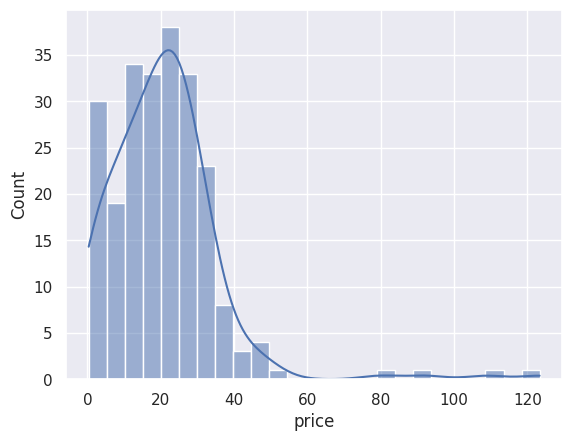

In [60]:
fig = sns.histplot(product_prices_df, x="price", kde=True)
plt.show()

In [72]:
#Our price z-score
avg_price = product_prices_df["price"].mean()
std_price = product_prices_df["price"].std()
zscore = round((our_price - avg_price) / std_price, 2)
print ("ZSCORE of our product is :", zscore)
print (f"Our price is {zscore} standard deviation above the avg_price")

ZSCORE of our product is : 0.66
Our price is 0.66 standard deviation above the avg_price


In [80]:
#Percentile 
our_price_percentile = round((product_prices_df["price"] < our_price).mean() * 100, 2)
print (f"{our_price_percentile}% of competitors are selling cheaper than us.")

84.78% of competitors are selling cheaper than us.


PRICE RULES : 
- price < median : competitve price 
- median < price < Q3 : expensive but reasonable 
- Q3 < price : too much expensive need to change 

In [92]:
q_3 = product_prices_df["price"].quantile(0.75)

product_prices_df["class"] = np.select(
    [
        product_prices_df["price"] < median_price,
        product_prices_df["price"] <= q_3,
        product_prices_df["price"] > q_3,
    ],
    [
        "Competitive",
        "Expensive but acceptable",
        "Exorbitant",
    ],
    default="unknown",
)

product_prices_df

,price,class
0,29.52,Exorbitant
1,17.21,Competitive
2,27.25,Exorbitant
3,13.74,Competitive
4,21.80,Expensive but acceptable
...,...,...
225,4.49,Competitive
226,31.70,Exorbitant
227,1.25,Competitive
228,22.98,Expensive but acceptable


In [118]:
fig = px.histogram(
    product_prices_df,
    x="price",
    color="class",
    color_discrete_map={
        "Competitive": "green",
        "Expensive but acceptable": "blue",
        "Exorbitant": "red",
    },
    barmode="overlay",
    opacity=0.65,
    nbins=30,
    width=1500,
    height=700,
    title="Price Distribution by Class",
    labels={"price": "Price", "class": "Price Class"},
)

for x, color in [(q_3, "blue"), (median_price, "green"), (our_price, "red")]:
    fig.add_vline(
        x=x,
        line_dash="dash",
        line_color=color,
    )

annotations = [
    (q_3, f"Q3: {q_3:.2f}", "blue", -45),
    (median_price, f"Median: {median_price:.2f}", "green", 0),
    (our_price, f"Our price: {our_price:.2f}$", "red", -90),
]

for x, text, color, yshift in annotations:
    fig.add_annotation(
        x=x,
        y=1,
        yref="paper",
        text=text,
        textangle=0,
        yshift=yshift,
        font=dict(color=color),
        showarrow=False,
        xanchor="left",
        yanchor="top",
    )

fig.show()

### QUESTION:

### Can we reduct the prduct price under 27$ ?